# Initial Exploration of Biblical Texts

Name: Wesley Stevick

Date: 09-09

This problem set must accomplish the following tasks:
1. Read in 'SF_2009-01-20_GRC_TISCHENDORF_(TISCHENDORF GREEK NT(STRONGS)).xml' and save data to a dataframe (one word per row).
2. Parse the rmac codes.
3. Read in 'strongs-dictionary.xhtml' and save data to a dataframe (one term per row).
4. Compute top 50 lemmas by frequency

**Zipf's law**: in natural language, the frequency of a word is inversely proportion to its rank. e.g. the second more frequent word occurs half as often as the first most frequent word. So the top few words cover a huge fraction of the text.
If you have $n$ total tokens and sorted counts $f_1, f_2, \ldots, f_3$, the coverage of the first k terms is $C_k = \frac{\sum_{i=1}^k f_i}{n}$
The ideal Zipf prediction is $p(k) \propto 1/k$. For a finite vocabulary size of $n$, the ideal Zipf prediction is $p(k) = \frac{1/k}{\sum_{i=1}^n 1/i}$

6. Plot the coverage of the top 20 lemmas and list them in a table along with their Strong's definitions. On this same plot, plot the ideal Zipf prediction for a finite vocabulary size.
7. Identify a way to drop out the content-less words and then plot the coverage of these new top 20 lemmas and list them in a table along with their Strong's definitions. On this same plot, plot the ideal Zipf prediction for a finite vocabulary size.

8. Pickle your dataframes.

In [1]:
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
import re

## Problem 1.

In [2]:
tischendorf = BeautifulSoup(
    open(
        os.path.join(
            "data", "SF_2009-01-20_GRC_TISCHENDORF_(TISCHENDORF GREEK NT(STRONGS)).xml"
        )
    ),
    "xml",
)

In [3]:
df = pd.DataFrame(
    [
        (
            e.text,
            e["rmac"],
            e.attrs.get("str"),
            e.find_parent("BIBLEBOOK")["bnumber"],
            e.find_parent("CHAPTER")["cnumber"],
            e.find_parent("VERS")["vnumber"],
        )
        for e in tischendorf("gr")
    ],
    columns=["word", "rmac", "strong", "book", "chapter", "verse"],
)

df["word"] = df["word"].str.strip()
df["rmac"] = df["rmac"].str.upper()
df["book"] = df["book"].astype(int)
df["chapter"] = df["chapter"].astype(int)
df["verse"] = df["verse"].astype(int)

Some of the words don't have strong numbers. I had hoped that by accident the numbers were accidentally ommited from certain entries and tried filling them in with word-number pairs from elsewhere in the text, but that didn't work.

In [4]:
m = pd.Series(df["strong"], index=df["word"])

m.dropna(inplace=True)

unique_strongless_words = df.loc[~df["strong"].astype(bool), "word"].unique()

sum(w in m for w in unique_strongless_words)

0

In [5]:
df = df[df["strong"].astype(bool)]
df["strong"] = df["strong"].astype(int)

So instead I'm dropping every word without a strong number.

## Problem 2.

In [6]:
def parse(rmac):
    *rmac, suffix = rmac.split("-")
    translated_suffix = {
        "S": "superlative",
        "C": "comparative",
        "ABB": "abbreviated form",
        "I": "interrogative",
        "N": "negative",
        "K": "kai",
        "ATT": "attic greek form",
    }.get(suffix, "").capitalize()
    if not translated_suffix:
        rmac = "-".join([*rmac, suffix])
    else:
        rmac = "-".join(rmac)
    try:
        return {
            "ADV": "adverb or adverb and particle combined",
            "CONJ": "conjunction or conjunctive particle",
            "COND": "conditional particle or conjunction",
            "PRT": "particle, disjunctive particle",
            "PREP": "preposition",
            "INJ": "interjection",
            "ARAM": "aramaic transliterated word (indeclinable)",
            "HEB": "hebrew transliterated word (indeclinable)",
            "N-PRI": "indeclinable proper noun",
            "A-NUI": "indeclinable numeral (adjective)",
            "N-LI": "indeclinable letter (noun)",
            "N-OI": "indeclinable noun of other type",
        }[rmac].capitalize() + (" - " + translated_suffix if translated_suffix else "")
    except KeyError:
        prefix, rest = rmac.split("-", 1)
        parts = []
        parts.append(
            {
                "N": "noun",
                "A": "adjective",
                "R": "relative pronoun",
                "C": "reciprocal pronoun",
                "D": "demonstrative pronoun",
                "T": "definite article",
                "K": "correlative pronoun",
                "I": "interrogative pronoun",
                "X": "indefinite pronoun",
                "Q": "correlative or interrogative pronoun",
                "F": "reflexive pronoun",
                "S": "possessive adjective",
                "P": "personal pronoun",
                "V": "Verb",
            }[prefix].capitalize()
        )
        # verbs are parsed seperately
        if prefix == "V":
            rest = rest.replace("-", "")
            if rest[0] == "2":
                _, *rest = rest
                parts.append("Second")
            parts.append(
                {
                    "P": "present",
                    "I": "imperfect",
                    "F": "future",
                    "A": "aorist",
                    "R": "perfect",
                    "L": "pluperfect",
                }[rest[0]].capitalize()
            )
            parts.append(
                {
                    "A": "active",
                    "M": "middle",
                    "P": "passive",
                    "E": "either middle or passive",
                    "D": "middle deponent",
                    "O": "passive deponent",
                    "N": "middle or passive deponent",
                }[rest[1]].capitalize()
            )
            parts.append(
                {
                    "I": "indicative",
                    "S": "subjunctive",
                    "O": "optative",
                    "M": "imperative",
                    "N": "infinitive",
                    "P": "participle",
                    "R": "unspecified case letter R",
                }[rest[2]].capitalize()
            )
            rest = rest[3:]
            if rest:
                parts.append(
                    {
                        "1": "1st",
                        "2": "2nd",
                        "3": "3rd",
                        "N": "nominative",
                        "G": "genitive",
                        "D": "dative",
                        "A": "accusative",
                        "V": "vocative",
                    }[rest[0]].capitalize()
                )
                parts.append({"S": "Singular", "P": "Plural"}[rest[1]])
                if rest[2:]:
                    parts.append(
                        {"M": "Masculine", "F": "Feminine", "N": "Neuter"}[rest[2]]
                    )
        else:
            if rest[0] in "123":
                parts.append(
                    {
                        "1": "1st",
                        "2": "2nd",
                        "3": "3rd",
                    }[rest[0]]
                )
                _, *rest = rest
            case, *rest = rest
            parts.append(
                {
                    "N": "Nominative",
                    "V": "Vocative",
                    "G": "Genitive",
                    "D": "Dative",
                    "A": "Accusative",
                }[case]
            )
            if rest:
                number, *rest = rest
                parts.append({"S": "Singular", "P": "Plural"}[number])
            if rest:
                gender, *rest = rest
                parts.append({"M": "Masculine", "F": "Feminine", "N": "Neuter"}[gender])
        parts.append("".join(rest))
        return " - ".join(filter(None, parts)) + (
            " - " + translated_suffix if translated_suffix else ""
        )

In [7]:
df["parsed_rmac"] = df["rmac"].apply(parse)

df["parsed_rmac"]

0                   Noun - Nominative - Singular - Feminine
1                     Noun - Genitive - Singular - Feminine
2                    Noun - Genitive - Singular - Masculine
3                    Noun - Genitive - Singular - Masculine
4                    Noun - Genitive - Singular - Masculine
                                ...                        
137520    Definite article - Genitive - Singular - Mascu...
137521               Noun - Genitive - Singular - Masculine
137522               Noun - Genitive - Singular - Masculine
137523                                          Preposition
137524            Adjective - Genitive - Plural - Masculine
Name: parsed_rmac, Length: 137352, dtype: object

## Problem 3

In [9]:
strong_soup = BeautifulSoup(open("data/strongs-dictionary.xhtml"), "xml")
strong = pd.DataFrame(columns=["id", "original", "definition", "kjv"]).set_index("id")
for e in strong_soup("li", id=re.compile(r"nt:\d+")):
    kjv_e = e.find(class_="kjv_def")
    if kjv_e is None:
        kjv = ""
    else:
        kjv = kjv_e.text
    strong.loc[int(e["value"])] = [
        str(e.find("i").string).strip(),
        str(e.text).strip(),
        str(kjv).strip(),
    ]
with open(os.path.join("pickles", "dictionary.pickle"), "wb") as f:
    pickle.dump(strong, f)
strong

,original,definition,kjv
id,,,
1,Α,Α of Hebrew origin; the first letter of the al...,Alpha
2,Ἀαρών,"Ἀαρών of Hebrew origin (אַהֲרוֹן); Aaron, the br...",Aaron
3,Ἀβαδδών,Ἀβαδδών of Hebrew origin (אֲבַדּוֹן); a destroyi...,Abaddon
4,ἀβαρής,ἀβαρής from Α (as a negative particle) and βάρ...,from being burdensome
5,Ἀββᾶ,Ἀββᾶ of Chaldee origin (אַב); father as a vocat...,Abba
...,...,...,...
5620,ὥστε,"ὥστε from ὡς and τέ; so too, i.e. thus therefo...","(insomuch) as, so that (then), (insomuch) that..."
5621,ὠτίον,"ὠτίον diminutive of οὖς; an earlet, i.e. one o...",ear
5622,ὠφέλεια,ὠφέλεια from a derivative of the base of ὠφέλι...,"advantage, profit"


In [10]:
df["strong_definition"] = strong.loc[df["strong"], "definition"].values

Just to double-check that each word corresponds to its strong index

In [11]:
for i in range(10):
    print(df.loc[i, "word"], strong.loc[df.iloc[i]["strong"], "original"])

Βίβλος βίβλος
γενέσεως γένεσις
Ἰησοῦ Ἰησοῦς
Χριστοῦ Χριστός
υἱοῦ υἱός
Δαυεὶδ Δαβίδ
υἱοῦ υἱός
Ἀβραάμ. Ἀβραάμ
Ἀβραὰμ Ἀβραάμ
ἐγέννησεν γεννάω


## Problem 4

In [12]:
frequencies = df["strong"].value_counts()
top_50 = frequencies.index[:50]
pd.concat([frequencies.iloc[:50], strong.loc[top_50, "definition"]], axis=1)

,count,definition
strong,,
3588,19760,"ὁ, including the feminine he, and the neuter t..."
2532,8968,"καί apparently, a primary particle, having a c..."
846,5556,αὐτός from the particle au (perhaps akin to th...
1161,2771,δέ a primary particle (adversative or continua...
1722,2740,ἐν a primary preposition denoting (fixed) posi...
1510,2459,εἰμί the first person singular present indicat...
3004,2251,"λέγω a primary verb; properly, to ""lay"" forth,..."
5210,1828,ὑμεῖς irregular plural of σύ; you (as subjecti...
1519,1764,εἰς a primary preposition; to or into (indicat...


## Problem 6

In [13]:
total_tokens = len(df)
vocab_size = len(frequencies)
denominator = sum(1 / i for i in range(1, vocab_size + 1))
total_count = 0
zipf_df = pd.DataFrame(
    columns=[
        "rank",
        "strong",
        "word",
        "definition",
        "coverage",
        "proportion",
        "predicted_proportion",
    ]
).set_index("rank")
for i in range(20):
    str_n = frequencies.index[i]
    word = strong.loc[str_n, "original"]
    definition = strong.loc[str_n, "definition"]
    count = frequencies.iloc[i]
    proportion = count / total_tokens
    total_count += count
    coverage = total_count / total_tokens
    rank = i + 1
    predicted_proportion = 1 / rank / denominator
    zipf_df.loc[rank] = [
        str_n,
        word,
        definition,
        coverage,
        proportion,
        predicted_proportion,
    ]

zipf_df

,strong,word,definition,coverage,proportion,predicted_proportion
rank,,,,,,
1,3588,ὁ,"ὁ, including the feminine he, and the neuter t...",0.143864,0.143864,0.109140
2,2532,καί,"καί apparently, a primary particle, having a c...",0.209156,0.065292,0.054570
3,846,αὐτός,αὐτός from the particle au (perhaps akin to th...,0.249607,0.040451,0.036380
4,1161,δέ,δέ a primary particle (adversative or continua...,0.269781,0.020174,0.027285
5,1722,ἐν,ἐν a primary preposition denoting (fixed) posi...,0.289730,0.019949,0.021828
6,1510,εἰμί,εἰμί the first person singular present indicat...,0.307633,0.017903,0.018190
7,3004,λέγω,"λέγω a primary verb; properly, to ""lay"" forth,...",0.324021,0.016389,0.015591
8,5210,ὑμεῖς,ὑμεῖς irregular plural of σύ; you (as subjecti...,0.337330,0.013309,0.013643
9,1519,εἰς,εἰς a primary preposition; to or into (indicat...,0.350173,0.012843,0.012127


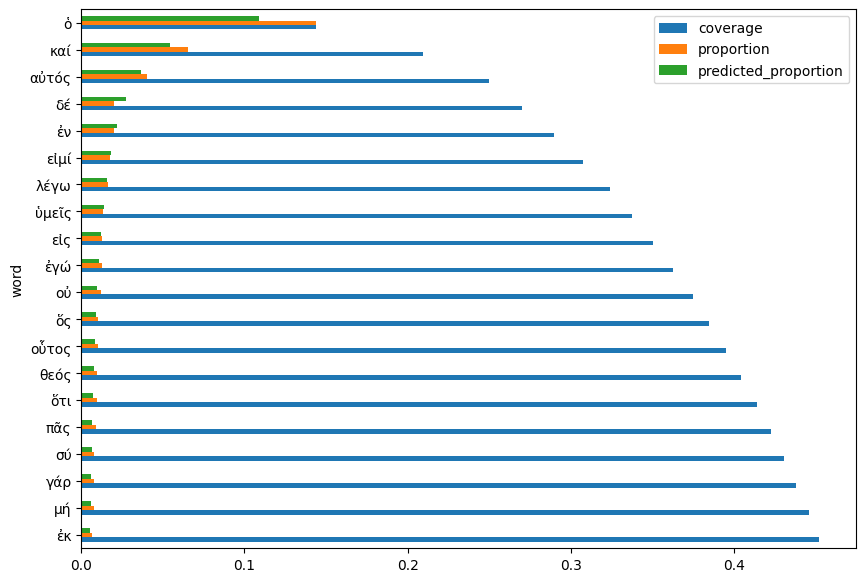

In [14]:
zipf_df[["coverage", "proportion", "predicted_proportion", "word"]][::-1].plot.barh(
    x="word"
).figure.set_size_inches(10, 7);

The problemset said to put the definitions and coverages on the same plot, but the definitions are really long and would have taken up all the plot space. Instead I'm displaying everything in one table, and everything except the definition on one plot.

## Problem 7

I don't know what you mean by content-less words.

## Problem 8

In [15]:
os.makedirs("pickles", exist_ok=True)
with open(os.path.join("pickles", "nt.pickle"), "wb") as f:
    pickle.dump(df, f)
with open(os.path.join("pickles", "dictionary.pickle"), "wb") as f:
    pickle.dump(strong, f)
with open(os.path.join("pickles", "zipf-top20.pickle"), "wb") as f:
    pickle.dump(zipf_df, f)

https://chatgpt.com/share/68c167b5-bef8-8002-8217-6ac156093091